# Creating sine wave

In [1]:
figsize = (25, 6.25)
colors = "#323031", "#308E91", "#34369D", "#5E2A7E", "#5E2A7E", "#6F3384"

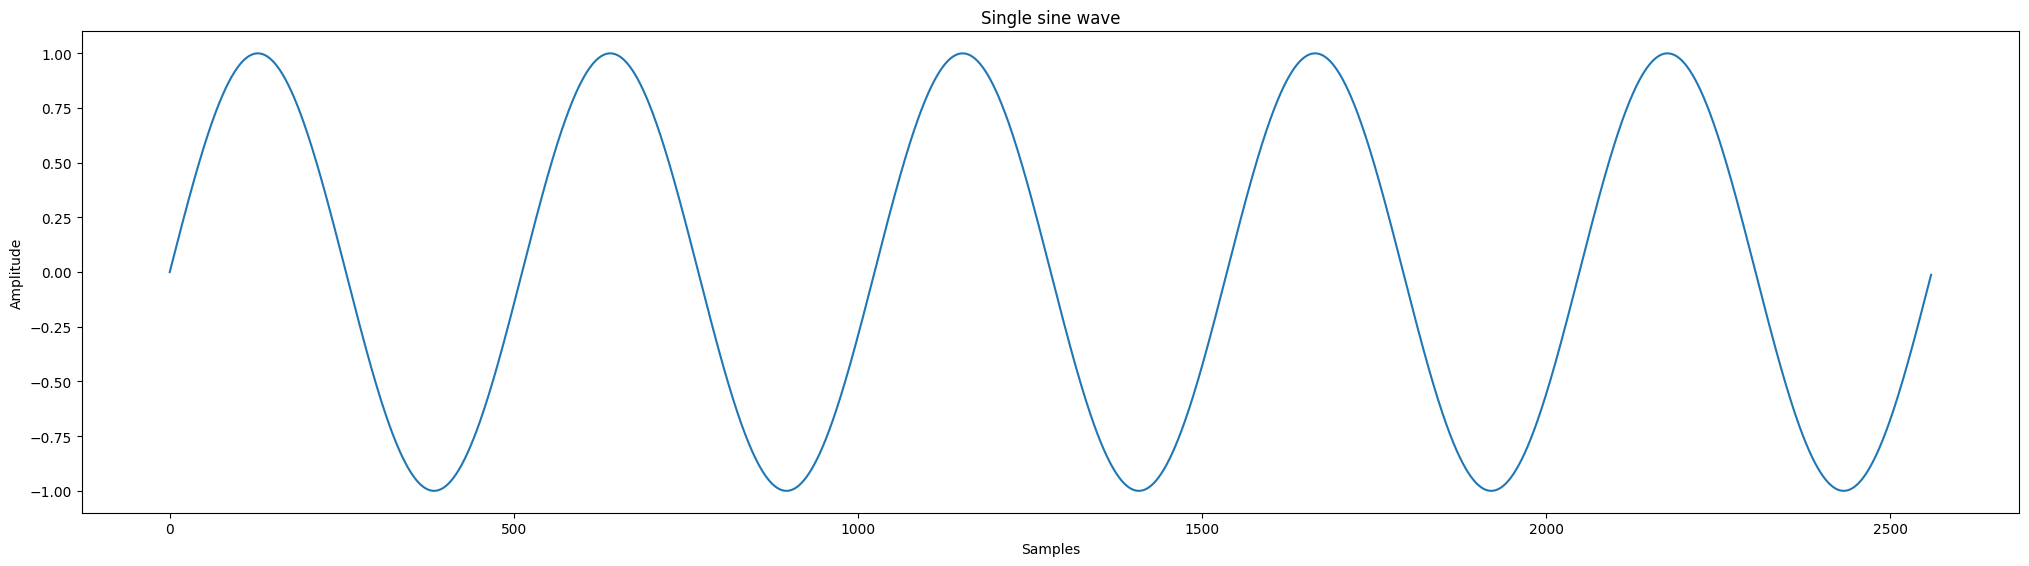

In [2]:
import matplotlib.pyplot as plt

from engine import SineOscillator, SquareOscillator

plt.figure(figsize=figsize)
plt.title("Single sine wave")

osc = SineOscillator(frequency=1, amplitude=1, phase=0, sample_rate=512)
samples = osc.get_samples(n=512 * 5)

plt.ylabel("Amplitude")
plt.xlabel("Samples")
plt.plot(samples)
plt.show()

## Square

ValueError: Unknown square wave mode: bandlimited. Available modes: ['ideal', 'ideal_smooth', 'soft']

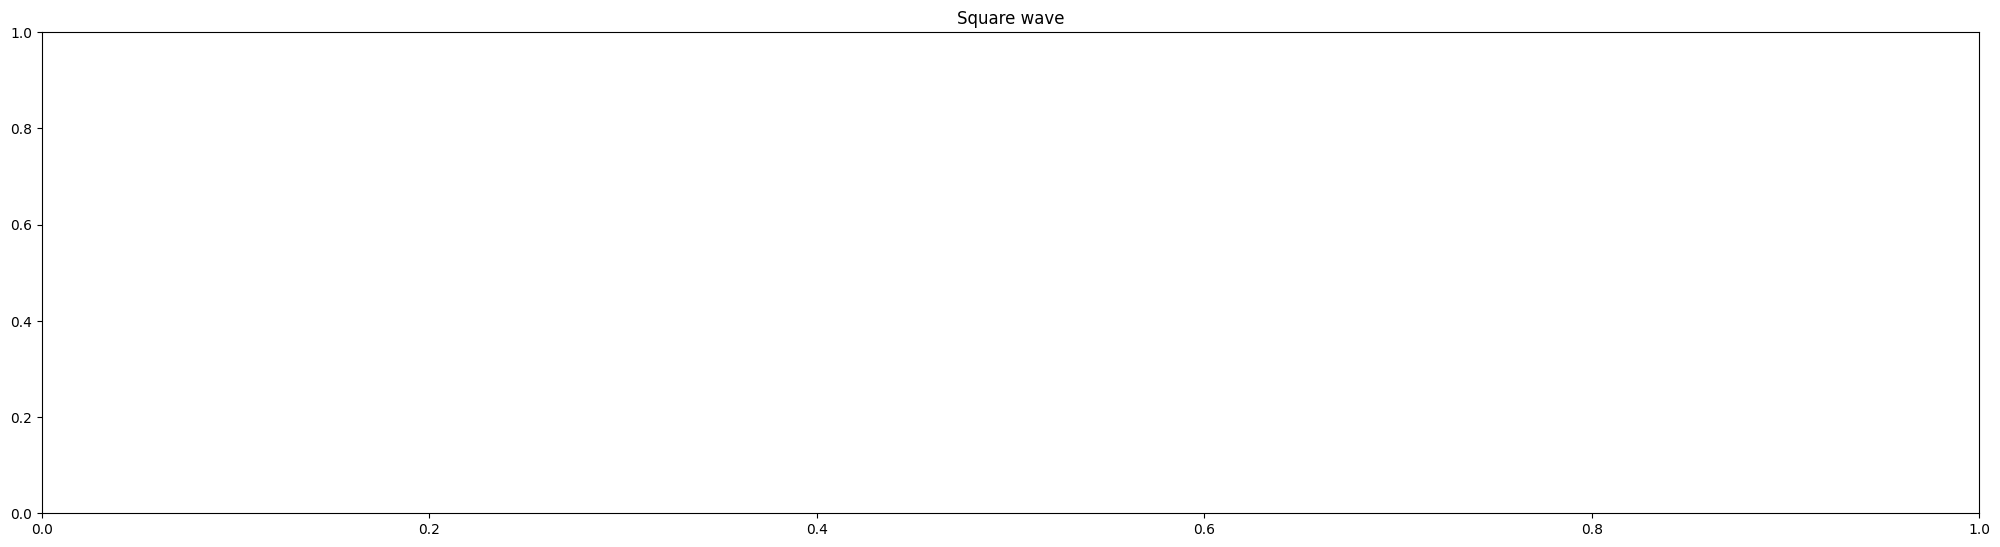

In [3]:
plt.figure(figsize=figsize)
plt.title("Square wave")

osc = SquareOscillator(
    frequency=1, amplitude=0.1, phase=0, sample_rate=512, mode="bandlimited"
)

samples = osc.get_samples(n=512 * 5)

plt.ylabel("Amplitude")
plt.xlabel("Samples")
plt.plot(samples)
plt.show()

## Multiple square waves

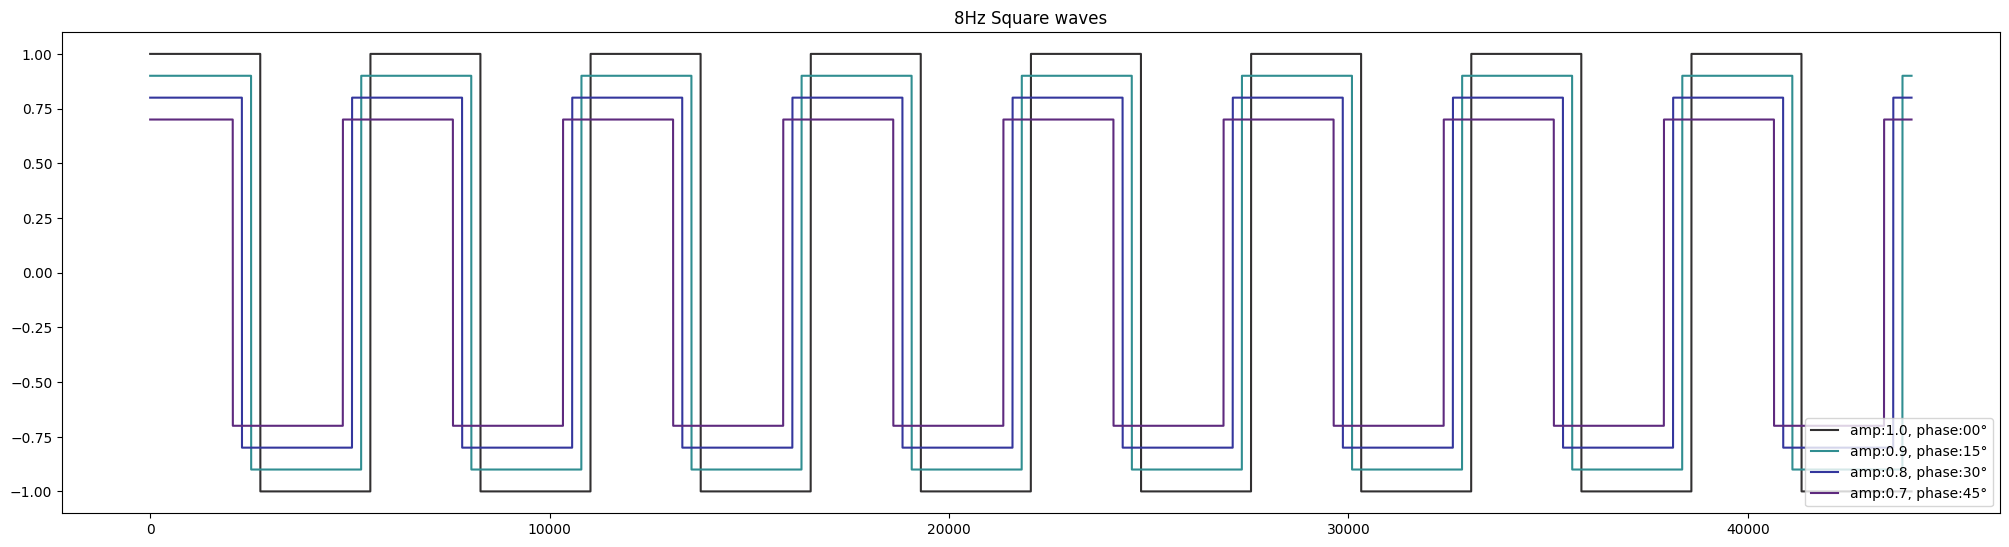

In [14]:
import matplotlib.pyplot as plt

from engine import SquareOscillator


def plot_osc(osc, name=""):
    plt.figure(figsize=figsize)

    f = 8
    plt.title(f"{f}Hz {name} waves")

    for a, p, c in zip([1.0, 0.9, 0.8, 0.7], [0, 15, 30, 45], colors, strict=False):
        oscillator = osc(frequency=f, amplitude=a, phase=p, mode="ideal")
        plt.plot(oscillator.get_samples(), color=c, label=f"amp:{a}, phase:{p:02}°")

    plt.legend(loc="lower right")


plot_osc(SquareOscillator, "Square")

## Triangle

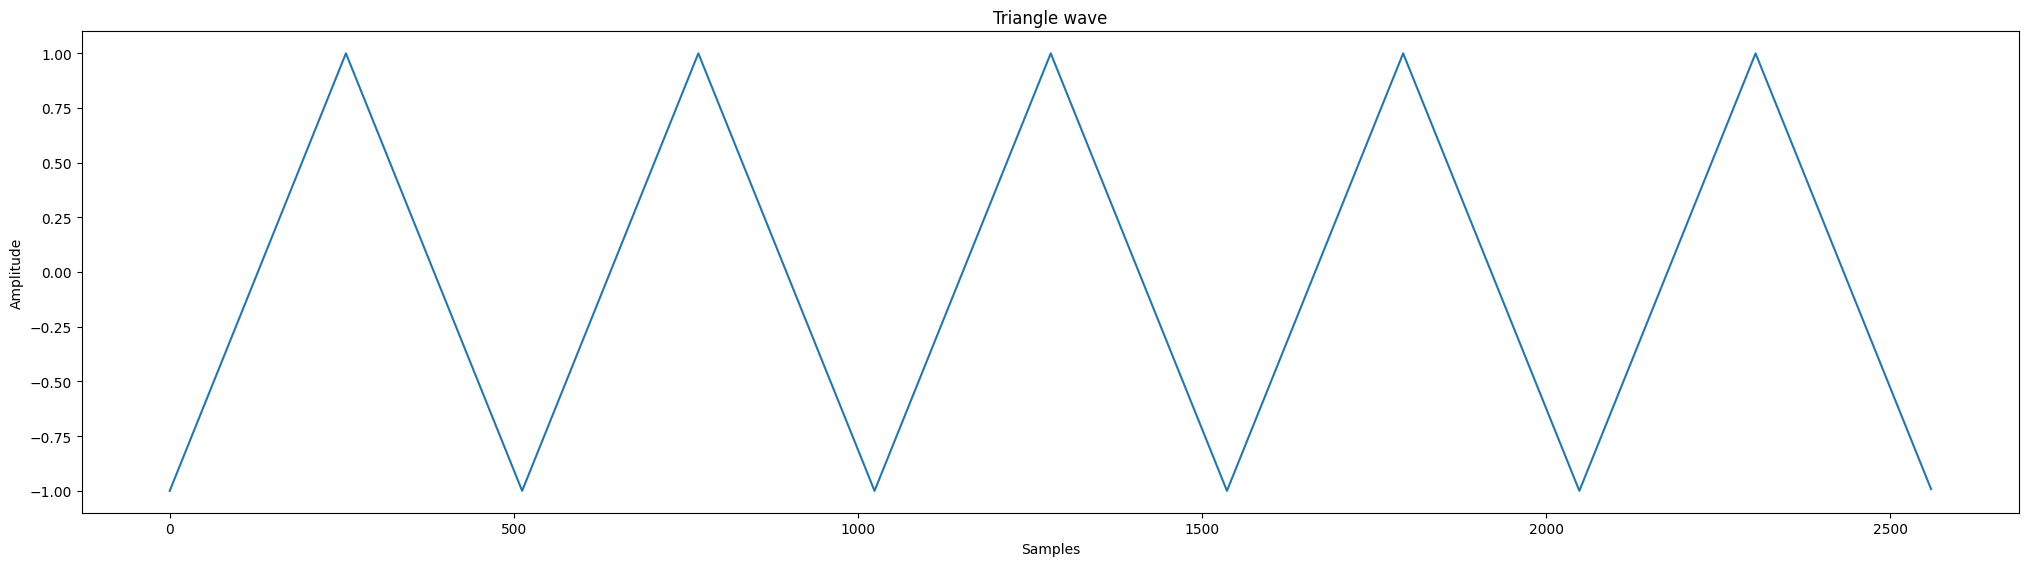

In [15]:
from engine import TriangleOscillator

plt.figure(figsize=figsize)
plt.title("Triangle wave")

osc = TriangleOscillator(frequency=1, amplitude=1, phase=0, sample_rate=512)
samples = osc.get_samples(n=512 * 5)

plt.ylabel("Amplitude")
plt.xlabel("Samples")
plt.plot(samples)
plt.show()

## Sawtooth

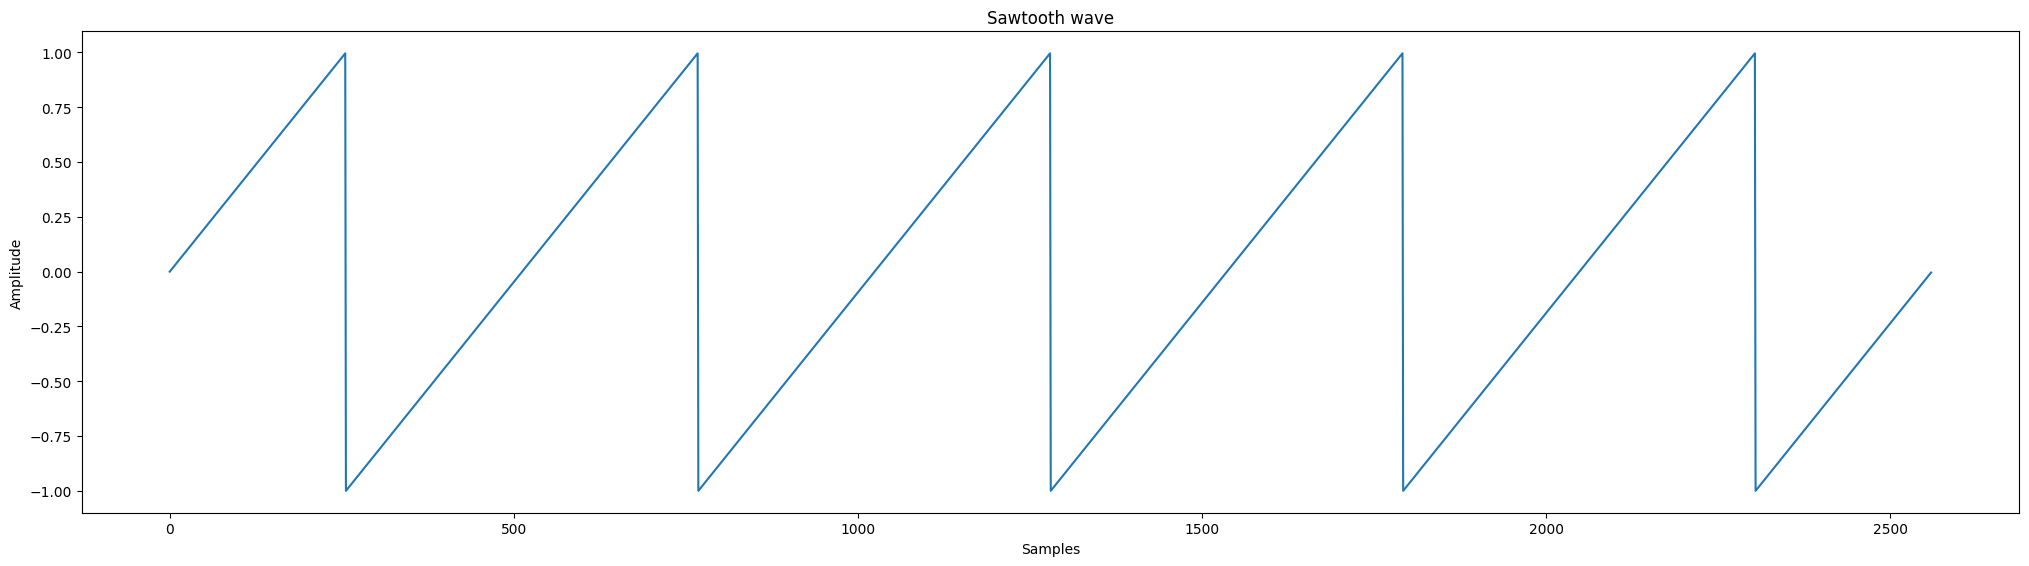

In [16]:
from engine import SawtoothOscillator

plt.figure(figsize=figsize)
plt.title("Sawtooth wave")

osc = SawtoothOscillator(frequency=1, amplitude=1, phase=0, sample_rate=512)
samples = osc.get_samples(n=512 * 5)

plt.ylabel("Amplitude")
plt.xlabel("Samples")
plt.plot(samples)
plt.show()

## Plotting the frequency spectrum of different waveforms

In [17]:
import numpy as np

figsize = (25, 6.25)
colors = "#323031", "#308E91", "#34369D", "#5E2A7E", "#5E2A7E", "#6F3384"


def fplot_xy(wave, fslice=slice(0, 100), sample_rate=44100):
    fd = np.fft.fft(wave)
    fd_mag = np.abs(fd)
    x = np.linspace(0, sample_rate, len(wave))
    y = fd_mag * 2 / sample_rate
    return x[fslice], y[fslice]


def plot(
    xy,
    r=1,
    c=1,
    i=1,
    title="",
    xlabel="",
    ylabel="",
    yticks=None,
    xticks=None,
    **plot_kwargs,
):
    plt.subplot(r, c, i)
    plt.title(title)
    if len(xy) == 2:
        plt.plot(*xy, **plot_kwargs)
    else:
        plt.plot(xy, **plot_kwargs)

    if xticks is not None:
        plt.xticks(xticks)
    if yticks is not None:
        plt.yticks(yticks)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)

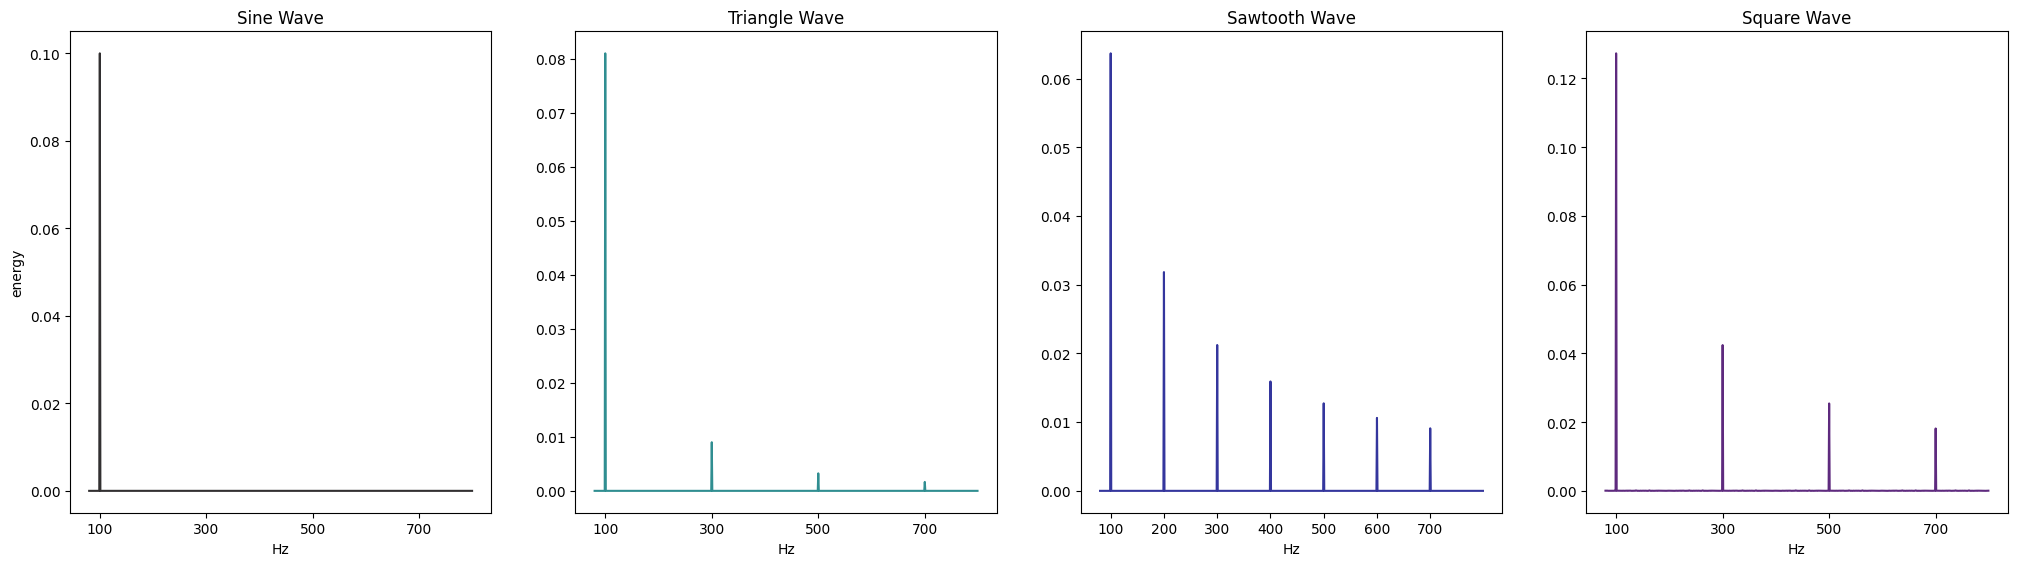

In [18]:
from engine import SawtoothOscillator, SquareOscillator, TriangleOscillator

freq = 100
fslice = slice(80, 800)
fig = plt.figure(figsize=figsize)

osc = SineOscillator(frequency=freq)
x, y = fplot_xy(osc.get_samples(), fslice)
plot(
    (x, y),
    1,
    4,
    1,
    "Sine Wave",
    "Hz",
    "energy",
    color=colors[0],
    xticks=[100, 300, 500, 700],
)

osc = TriangleOscillator(frequency=freq)
x, y = fplot_xy(osc.get_samples(), fslice)
plot(
    (x, y), 1, 4, 2, "Triangle Wave", "Hz", color=colors[1], xticks=[100, 300, 500, 700]
)

osc = SawtoothOscillator(frequency=freq)
x, y = fplot_xy(osc.get_samples(), fslice)
plot(
    (x, y),
    1,
    4,
    3,
    "Sawtooth Wave",
    "Hz",
    color=colors[2],
    xticks=[100, 200, 300, 400, 500, 600, 700],
)

osc = SquareOscillator(frequency=freq)
x, y = fplot_xy(osc.get_samples(), fslice)
plot((x, y), 1, 4, 4, "Square Wave", "Hz", color=colors[3], xticks=[100, 300, 500, 700])